# Model Comparison Analysis

Compare the prediction performance of the three schemes:

- Scheme 1 (RNN-ObsStep): Observation-step RNN

- Scheme 2 (RNN-DailyStep): Daily-step RNN

- Scheme 3 (RF-Baseline): Random Forest baseline

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
import json


## 1. Load Model Prediction Results

Specify the output directories for the three models

In [10]:
# Specify the model output directory (needs to be modified according to actual training results)
outputs_dir = Path('../outputs')

# Find the latest model output
rf_dirs = sorted(outputs_dir.glob('*rf*'))
rnn_obs_dirs = sorted(outputs_dir.glob('*rnn_obs*'))
rnn_daily_dirs = sorted(outputs_dir.glob('*rnn_daily*'))

if not rf_dirs or not rnn_obs_dirs or not rnn_daily_dirs:
    print('Please train three models first!')
    print(f'RF: {len(rf_dirs)}, RNN-Obs: {len(rnn_obs_dirs)}, RNN-Daily: {len(rnn_daily_dirs)}')
else:
    # Use the latest model
    rf_dir = rf_dirs[-1]
    rnn_obs_dir = rnn_obs_dirs[-1]
    rnn_daily_dir = rnn_daily_dirs[-1]

    print(f'RF: {rf_dir.name}')
    print(f'RNN-Obs: {rnn_obs_dir.name}')
    print(f'RNN-Daily: {rnn_daily_dir.name}')

    with open(rf_dir / 'metrics.json') as f:
        rf_metrics = json.load(f)
    with open(rf_dir / 'predictions.pkl', 'rb') as f:
        rf_predictions = pickle.load(f)
    with open(rnn_obs_dir / 'predictions.pkl', 'rb') as f:
        rnn_obs_predictions = pickle.load(f)
    with open(rnn_daily_dir / 'predictions.pkl', 'rb') as f:
        rnn_daily_predictions = pickle.load(f)

RF: train_rf_20251117_051850
RNN-Obs: rnn_obs_20251117_052303
RNN-Daily: rnn_daily_20251117_051833


In [11]:
rf_predictions

{'train': {'true': array([-0.52,  0.87,  0.15, ...,  9.26,  1.84,  1.44], shape=(31407,)),
  'pred': array([1.80457803, 1.74041883, 1.19769805, ..., 4.96339076, 3.68804404,
         3.89025714], shape=(31407,))},
 'val': {'true': array([-0.48,  1.48, -0.16, ...,  4.48,  4.16,  2.7 ], shape=(3434,)),
  'pred': array([ 2.29081608,  4.64006763,  4.01332422, ..., 19.58336369,
         18.65301094, 16.45208552], shape=(3434,))}}

## 2. Evaluation Metrics Comparison

In [12]:
metrics_data = []

# RF
metrics_data.append(
    {
        'Model': 'RF-Baseline',
        'Train Loss':  '-',
        'Train RMSE': rf_metrics['train']['rmse'],
        'Train MAE': rf_metrics['train']['mae'],
        'Train R²': rf_metrics['train']['r2'],
        'Val Loss': '-',
        'Val RMSE': rf_metrics['val']['rmse'],
        'Val MAE': rf_metrics['val']['mae'],
        'Val R²': rf_metrics['val']['r2'],
    }
)

# RNN-Obs
metrics_data.append(
    {
        'Model': 'RNN-ObsStep',
        'Train Loss': rnn_obs_predictions['metrics']['train']['loss'],
        'Train RMSE': rnn_obs_predictions['metrics']['train']['rmse'],
        'Train MAE': rnn_obs_predictions['metrics']['train']['mae'],
        'Train R²': rnn_obs_predictions['metrics']['train'].get('r2', '-'),
        'Val Loss': rnn_obs_predictions['metrics']['val']['loss'],
        'Val RMSE': rnn_obs_predictions['metrics']['val']['rmse'],
        'Val MAE': rnn_obs_predictions['metrics']['val']['mae'],
        'Val R²': rnn_obs_predictions['metrics']['val'].get('r2', '-'),
    }
)

# RNN-Daily
metrics_data.append(
    {
        'Model': 'RNN-DailyStep',
        'Train Loss': rnn_daily_predictions['metrics']['train']['loss'],
        'Train RMSE': rnn_daily_predictions['metrics']['train']['rmse'],
        'Train MAE': rnn_daily_predictions['metrics']['train']['mae'],
        'Train R²': rnn_daily_predictions['metrics']['train'].get('r2', '-'),
        'Val Loss': rnn_daily_predictions['metrics']['val']['loss'],
        'Val RMSE': rnn_daily_predictions['metrics']['val']['rmse'],
        'Val MAE': rnn_daily_predictions['metrics']['val']['mae'],
        'Val R²': rnn_daily_predictions['metrics']['val'].get('r2', '-'),
    }
)

# Create a comparison table
metrics_df = pd.DataFrame(metrics_data)
print('\n' + '=' * 80)
print('Model Performance Comparison')
print('=' * 80)
print(metrics_df.to_string(index=False))
print('=' * 80)

comparison_dir = Path('../outputs/model_comparison')
comparison_dir.mkdir(exist_ok=True, parents=True)
metrics_df.to_csv(comparison_dir / 'metrics_comparison.csv', index=False)
print(f'\nThe table has been saved to: {comparison_dir / "metrics_comparison.csv"}')


Model Performance Comparison
        Model Train Loss  Train RMSE  Train MAE  Train R²  Val Loss  Val RMSE   Val MAE   Val R²
  RF-Baseline          -   28.031803   7.247472  0.739318         - 38.443997 10.885880 0.397916
  RNN-ObsStep   0.338868    0.582124   0.417069  0.661132   0.52933  0.727550  0.522695 0.459673
RNN-DailyStep   0.515744    0.718153   0.526604  0.484256  0.553216  0.743785  0.551482 0.436747

The table has been saved to: ../outputs/model_comparison/metrics_comparison.csv


## 3. Visualization Comparison of Randomly Sampled Sequences

Randomly sample sequences from the validation set and compare the prediction performance of the three models.

Randomly sample 10 sequences for visualization comparison
RF predictions reorganized into 135 sequences


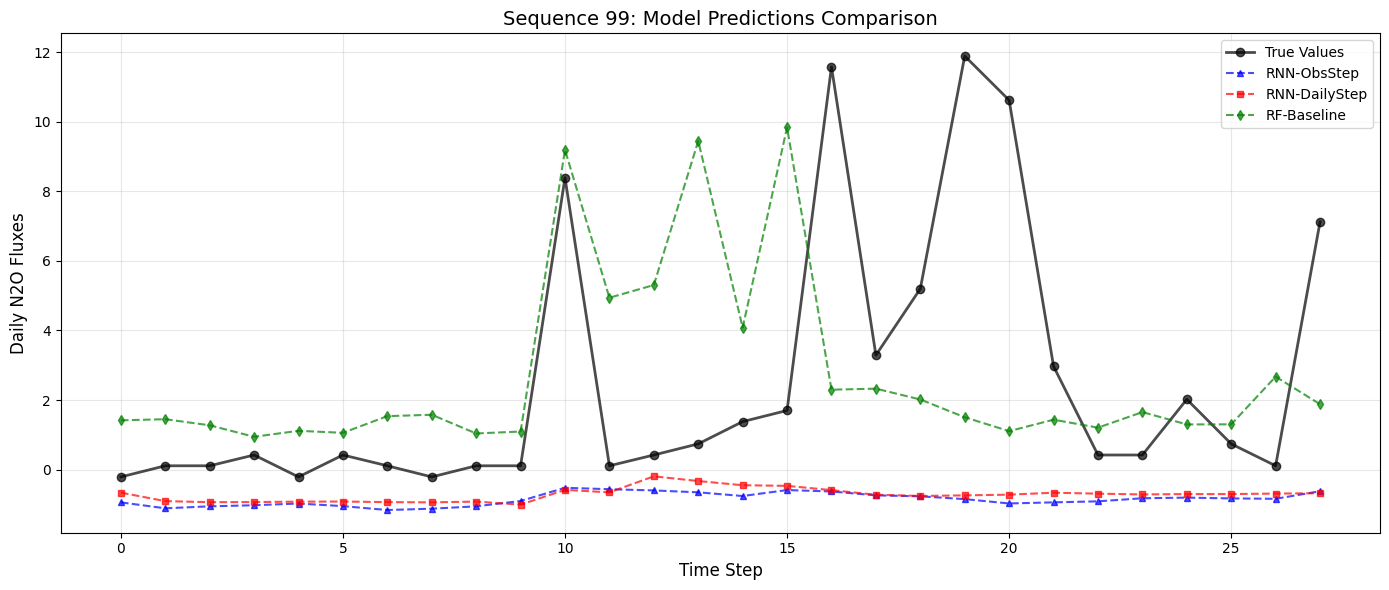

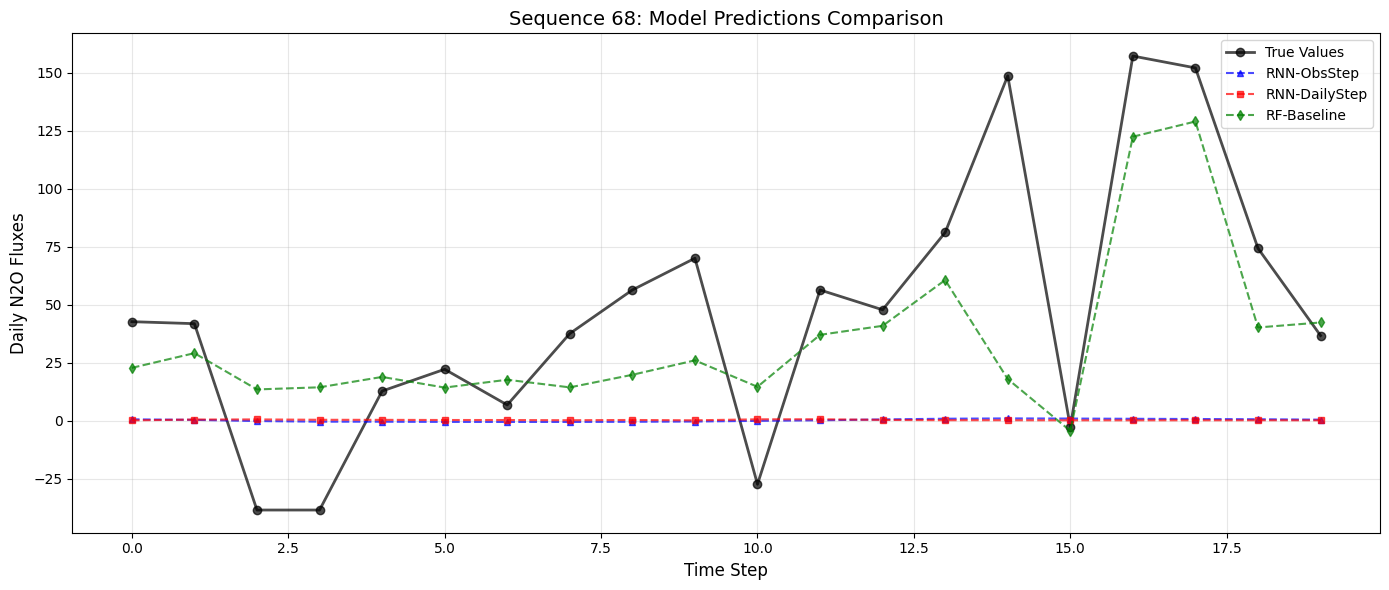

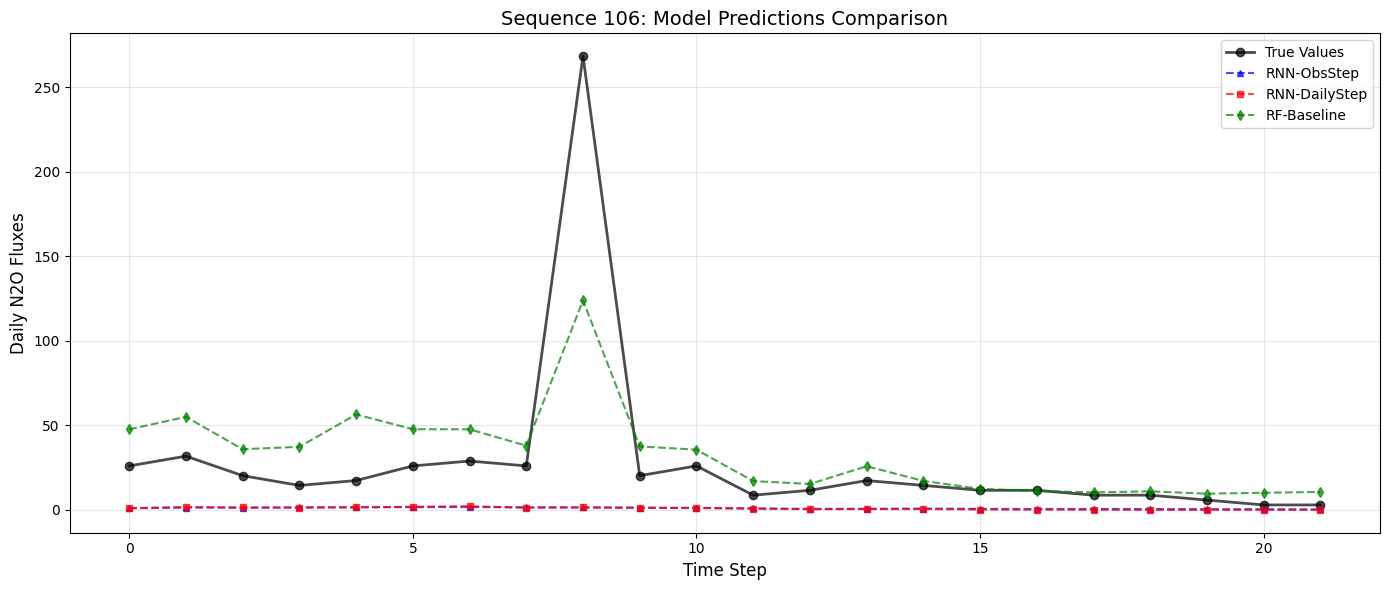

Sequence comparison plot has been saved to: ../outputs/model_comparison/figures


In [13]:
# Randomly sample sequences for visualization
np.random.seed(42)
n_samples = 10  # Sample 10 sequences

# Obtain sequence indices from RNN-Obs predictions (since the predictions are organized by sequence)
n_val_sequences = len(rnn_obs_predictions['val']['predictions'])
sample_indices = np.random.choice(
    n_val_sequences, size=min(n_samples, n_val_sequences), replace=False
)

print(f'Randomly sample {len(sample_indices)} sequences for visualization comparison')

# Reorganize RF predictions by sequence
# RF predictions are stored as flat arrays, need to reconstruct sequences
rf_val_pred = rf_predictions['val']['pred']
rf_val_true = rf_predictions['val']['true']

# Since RF predictions are in the same order as the flattened sequences,
# we need to split them back into sequences
rf_pred_by_seq = []
rf_true_by_seq = []
start_idx = 0
for seq_idx in range(n_val_sequences):
    seq_len = len(rnn_obs_predictions['val']['targets_original'][seq_idx])
    rf_pred_by_seq.append(rf_val_pred[start_idx : start_idx + seq_len])
    rf_true_by_seq.append(rf_val_true[start_idx : start_idx + seq_len])
    start_idx += seq_len

print(f'RF predictions reorganized into {len(rf_pred_by_seq)} sequences')

# Create Table of Figures
fig_dir = comparison_dir / 'figures'
fig_dir.mkdir(exist_ok=True)

# Create comparison plots for each sampled sequence
for idx, seq_idx in enumerate(sample_indices):
    fig, ax = plt.subplots(figsize=(14, 6))

    # Get the true value (using the original scale)
    true_values = rnn_obs_predictions['val']['targets_original'][seq_idx]

    # Obtain predictions from the three models (using the original scale)
    rnn_obs_pred = rnn_obs_predictions['val']['predictions'][seq_idx]
    rnn_daily_pred = rnn_daily_predictions['val']['predictions'][seq_idx]
    rf_pred = rf_pred_by_seq[seq_idx]

    # Drawing
    x = np.arange(len(true_values))
    ax.plot(x, true_values, 'ko-', label='True Values', linewidth=2, markersize=6, alpha=0.7)
    ax.plot(x, rnn_obs_pred, 'b^--', label='RNN-ObsStep', linewidth=1.5, markersize=5, alpha=0.7)
    ax.plot(
        x, rnn_daily_pred, 'rs--', label='RNN-DailyStep', linewidth=1.5, markersize=5, alpha=0.7
    )
    ax.plot(x, rf_pred, 'gd--', label='RF-Baseline', linewidth=1.5, markersize=5, alpha=0.7)

    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Daily N2O Fluxes', fontsize=12)
    ax.set_title(f'Sequence {seq_idx + 1}: Model Predictions Comparison', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(fig_dir / f'sequence_{seq_idx + 1}_comparison.png', dpi=150, bbox_inches='tight')

    # Show only the first 3
    if idx < 3:
        plt.show()
    else:
        plt.close()

print(f'Sequence comparison plot has been saved to: {fig_dir}')


## 4. Error Analysis

Analyze the error distribution and prediction performance of different models

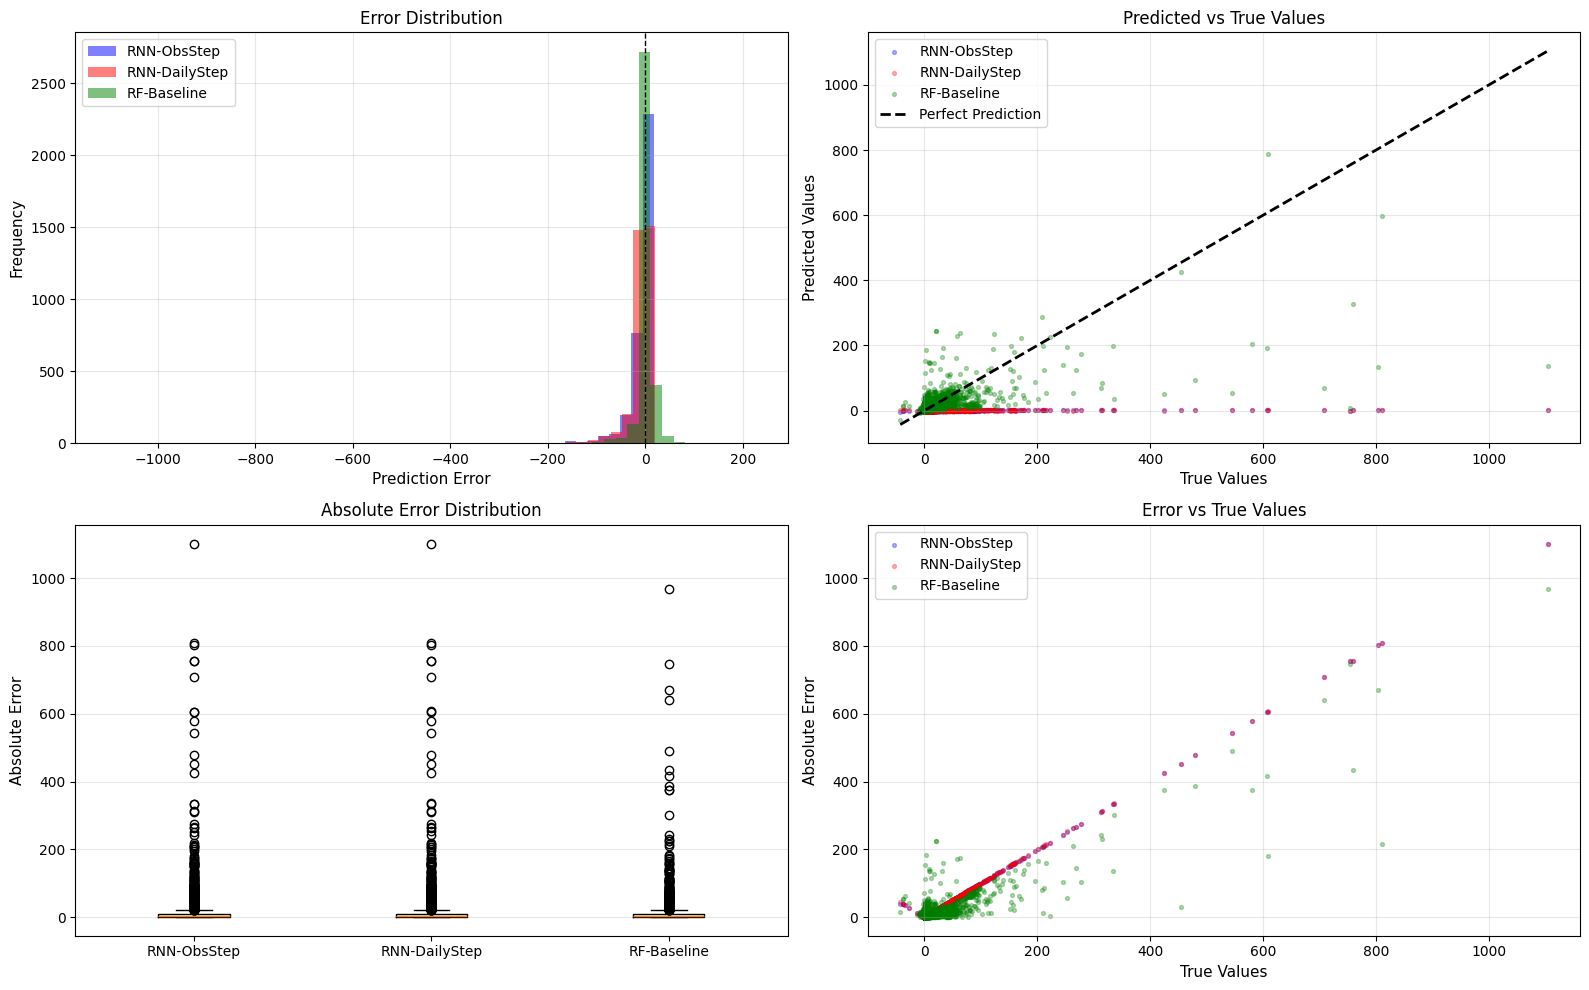

Error analysis plot has been saved to: ../outputs/model_comparison/figures/error_analysis.png


In [16]:
# Calculate the error for all validation set samples
def compute_errors(predictions, targets):
    """Calculate prediction error"""
    preds_flat = np.concatenate(predictions)
    targets_flat = np.concatenate(targets)
    errors = preds_flat - targets_flat
    abs_errors = np.abs(errors)
    return errors, abs_errors, preds_flat, targets_flat


# Calculate the errors of the three models
rnn_obs_errors, rnn_obs_abs_errors, rnn_obs_preds_all, rnn_obs_targets_all = compute_errors(
    rnn_obs_predictions['val']['predictions'], rnn_obs_predictions['val']['targets_original']
)

rnn_daily_errors, rnn_daily_abs_errors, rnn_daily_preds_all, rnn_daily_targets_all = compute_errors(
    rnn_daily_predictions['val']['predictions'], rnn_daily_predictions['val']['targets_original']
)

# RF errors (using flattened predictions)
rf_errors = rf_val_pred - rf_val_true
rf_abs_errors = np.abs(rf_errors)

# Visualize the error distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Error Distribution Histogram
axes[0, 0].hist(rnn_obs_errors, bins=50, alpha=0.5, label='RNN-ObsStep', color='blue')
axes[0, 0].hist(rnn_daily_errors, bins=50, alpha=0.5, label='RNN-DailyStep', color='red')
axes[0, 0].hist(rf_errors, bins=50, alpha=0.5, label='RF-Baseline', color='green')
axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Prediction Error', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Error Distribution', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Predicted vs Actual Scatter Plot
axes[0, 1].scatter(
    rnn_obs_targets_all, rnn_obs_preds_all, alpha=0.3, s=8, label='RNN-ObsStep', color='blue'
)
axes[0, 1].scatter(
    rnn_daily_targets_all, rnn_daily_preds_all, alpha=0.3, s=8, label='RNN-DailyStep', color='red'
)
axes[0, 1].scatter(rf_val_true, rf_val_pred, alpha=0.3, s=8, label='RF-Baseline', color='green')
max_val = max(
    rnn_obs_targets_all.max(), rnn_obs_preds_all.max(), rf_val_true.max(), rf_val_pred.max()
)
min_val = min(
    rnn_obs_targets_all.min(), rnn_obs_preds_all.min(), rf_val_true.min(), rf_val_pred.min()
)
axes[0, 1].plot(
    [min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction'
)
axes[0, 1].set_xlabel('True Values', fontsize=11)
axes[0, 1].set_ylabel('Predicted Values', fontsize=11)
axes[0, 1].set_title('Predicted vs True Values', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Absolute Error Distribution (Box Plot)
error_data = [rnn_obs_abs_errors, rnn_daily_abs_errors, rf_abs_errors]
axes[1, 0].boxplot(error_data, tick_labels=['RNN-ObsStep', 'RNN-DailyStep', 'RF-Baseline'])
axes[1, 0].set_ylabel('Absolute Error', fontsize=11)
axes[1, 0].set_title('Absolute Error Distribution', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Error varies with the true value
axes[1, 1].scatter(
    rnn_obs_targets_all, rnn_obs_abs_errors, alpha=0.3, s=8, label='RNN-ObsStep', color='blue'
)
axes[1, 1].scatter(
    rnn_daily_targets_all, rnn_daily_abs_errors, alpha=0.3, s=8, label='RNN-DailyStep', color='red'
)
axes[1, 1].scatter(rf_val_true, rf_abs_errors, alpha=0.3, s=8, label='RF-Baseline', color='green')
axes[1, 1].set_xlabel('True Values', fontsize=11)
axes[1, 1].set_ylabel('Absolute Error', fontsize=11)
axes[1, 1].set_title('Error vs True Values', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Error analysis plot has been saved to: {fig_dir / "error_analysis.png"}')


In [15]:
report_path = Path('../docs/models-comparation.md')
report_path.parent.mkdir(exist_ok=True, parents=True)

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('# N2O排放预测模型对比分析\n\n')
    f.write(f'生成时间: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n')

    f.write('## 1. 模型概述\n\n')
    f.write('本研究对比了三种N2O排放预测方案：\n\n')
    f.write('### 方案1: RNN-ObsStep（观测步长RNN）\n')
    f.write('- **特点**: 事件驱动，每个时间步对应一次观测\n')
    f.write('- **时间间隔**: 不均匀，作为输入特征\n')
    f.write('- **施肥特征**: 距上次施肥天数\n')
    f.write('- **损失计算**: 所有非padding位置\n\n')

    f.write('### 方案2: RNN-DailyStep（每日步长RNN）\n')
    f.write('- **特点**: 时间驱动，每个时间步对应一天\n')
    f.write('- **时间间隔**: 均匀（每天），由RNN步长隐式表达\n')
    f.write('- **施肥特征**: 当天施肥量\n')
    f.write('- **损失计算**: 只在真实观测点（observed_mask=True）\n\n')

    f.write('### 方案3: RF-Baseline（随机森林基线）\n')
    f.write('- **特点**: 每个时间点作为独立样本\n')
    f.write('- **特征**: 静态特征 + 当前时间步的动态特征\n\n')

    f.write('## 2. 性能对比\n\n')
    f.write('### 验证集评估指标\n\n')
    f.write(metrics_df.to_markdown(index=False))
    f.write('\n\n')

    f.write('## 3. 主要发现\n\n')

    # 找出最佳模型
    best_model_rmse = metrics_df.loc[metrics_df['Val RMSE'].idxmin(), 'Model']
    best_model_mae = metrics_df.loc[metrics_df['Val MAE'].idxmin(), 'Model']

    f.write('### 最佳性能\n\n')
    f.write(f'- **最低RMSE**: {best_model_rmse} (RMSE = {metrics_df["Val RMSE"].min():.4f})\n')
    f.write(f'- **最低MAE**: {best_model_mae} (MAE = {metrics_df["Val MAE"].min():.4f})\n\n')

    f.write('### 误差统计\n\n')
    f.write('| 模型 | 平均误差 | 中位数误差 | 标准差 | 95%分位数 |\n')
    f.write('|------|----------|-----------|--------|----------|\n')
    f.write(
        f'| RNN-ObsStep | {rnn_obs_errors.mean():.4f} | {np.median(rnn_obs_errors):.4f} | '
        f'{rnn_obs_errors.std():.4f} | {np.percentile(rnn_obs_abs_errors, 95):.4f} |\n'
    )
    f.write(
        f'| RNN-DailyStep | {rnn_daily_errors.mean():.4f} | {np.median(rnn_daily_errors):.4f} | '
        f'{rnn_daily_errors.std():.4f} | {np.percentile(rnn_daily_abs_errors, 95):.4f} |\n'
    )
    f.write(
        f'| RF-Baseline | {rf_errors.mean():.4f} | {np.median(rf_errors):.4f} | '
        f'{rf_errors.std():.4f} | {np.percentile(rf_abs_errors, 95):.4f} |\n\n'
    )

    f.write('## 4. 可视化结果\n\n')
    f.write('### 序列预测对比\n\n')
    f.write(f'随机采样了 {len(sample_indices)} 个验证集序列，对比三个模型的预测效果。\n')
    f.write(f'可视化图表保存在: `{fig_dir.relative_to(Path("../"))}/`\n\n')

    f.write('### 误差分析\n\n')
    f.write('误差分析包括：\n')
    f.write('1. 误差分布直方图\n')
    f.write('2. 预测值vs真实值散点图\n')
    f.write('3. 绝对误差箱线图\n')
    f.write('4. 误差随真实值的变化\n\n')

    f.write('详见: `outputs/model_comparison/figures/error_analysis.png`\n\n')

    f.write('## 5. 结论\n\n')
    f.write('通过对比三种方案，我们可以得出以下结论：\n\n')
    f.write('1. **RNN模型 vs 随机森林**: RNN模型能够捕捉时间序列的动态特性\n')
    f.write('2. **ObsStep vs DailyStep**: 两种时间建模方式各有优劣\n')
    f.write('   - ObsStep: 直接建模观测点，适合稀疏观测数据\n')
    f.write('   - DailyStep: 插值为每日数据，提供连续的预测，但依赖插值质量\n')
    f.write('3. **应用场景**: 根据具体需求选择合适的模型\n\n')

    f.write('## 6. 文件索引\n\n')
    f.write('- 模型配置: \n')
    f.write(f'  - RF: `{rf_dir.relative_to(Path("../"))}/config.json`\n')
    f.write(f'  - RNN-ObsStep: `{rnn_obs_dir.relative_to(Path("../"))}/config.json`\n')
    f.write(f'  - RNN-DailyStep: `{rnn_daily_dir.relative_to(Path("../"))}/config.json`\n')
    f.write('- 预测结果: `outputs/*/predictions.pkl`\n')
    f.write(f'- 可视化图表: `{fig_dir.relative_to(Path("../"))}/`\n')

print(f'\n{"=" * 60}')
print(f'对比报告已保存到: {report_path.absolute()}')
print(f'可视化图表已保存到: {fig_dir.absolute()}')
print(f'{"=" * 60}')
print('\n模型对比分析完成！')



对比报告已保存到: /Users/liaofeng/Documents/Codespace/N2O-pred/notebooks/../docs/models-comparation.md
可视化图表已保存到: /Users/liaofeng/Documents/Codespace/N2O-pred/notebooks/../outputs/model_comparison/figures

模型对比分析完成！
